In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
path = r"..\..\data\household_power_consumption.zip"
df = pd.read_csv(path, sep=';')
df


C:\Users\admin\AppData\Local\Temp\ipykernel_34600\803169723.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


Convert to datetime, set datetime index

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])
df.info()

C:\Users\admin\AppData\Local\Temp\ipykernel_34600\1823491321.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\admin\AppData\Local\Temp\ipykernel_34600\1823491321.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   datetime64[ns]
 2   Global_active_power    object        
 3   Global_reactive_power  object        
 4   Voltage                object        
 5   Global_intensity       object        
 6   Sub_metering_1         object        
 7   Sub_metering_2         object        
 8   Sub_metering_3         float64       
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 142.5+ MB


Setting datetime index

In [6]:
df['Datetime'] = pd.to_datetime(df['Date'], ' ' , df['Time'])
df.set_index('Datetime')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,2006-12-16,2025-07-13 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16
1,2006-12-16,2025-07-13 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16
2,2006-12-16,2025-07-13 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16
3,2006-12-16,2025-07-13 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16
4,2006-12-16,2025-07-13 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16


Time-based slicing df.loc['2020-01']

In [12]:
df_timebased = df.set_index('Datetime').loc['2006-12-16']
df_timebased.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16,2006-12-16,2025-07-13 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16,2006-12-16,2025-07-13 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16,2006-12-16,2025-07-13 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16,2006-12-16,2025-07-13 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16,2006-12-16,2025-07-13 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Resampling (resample('M'), resample('W'))

In [14]:
df_resampled_month = df.set_index('Datetime').resample('M')
df_resampled_week = df.set_index('Datetime').resample('W')

print("Monthly resampled data:")
print(df_resampled_month)

print("\nWeekly resampled data:")
print(df_resampled_week)

C:\Users\admin\AppData\Local\Temp\ipykernel_34600\490558980.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_resampled_month = df.set_index('Datetime').resample('M')


Monthly resampled data:
DatetimeIndexResampler [freq=<MonthEnd>, axis=0, closed=right, label=right, convention=start, origin=start_day]

Weekly resampled data:
DatetimeIndexResampler [freq=<Week: weekday=6>, axis=0, closed=right, label=right, convention=start, origin=start_day]


In [17]:
df['Global_active_power'] = df['Global_active_power'].replace('?', np.nan).astype(float)
df['Global_reactive_power'] = df['Global_reactive_power'].replace('?', np.nan).astype(float)
df['Voltage'] = df['Voltage'].replace('?', np.nan).astype(float)
df['Global_intensity'] = df['Global_intensity'].replace('?', np.nan).astype(float)
df['Sub_metering_1'] = df['Sub_metering_1'].replace('?', np.nan).astype(float)
df['Sub_metering_2'] = df['Sub_metering_2'].replace('?', np.nan).astype(float)
         
   

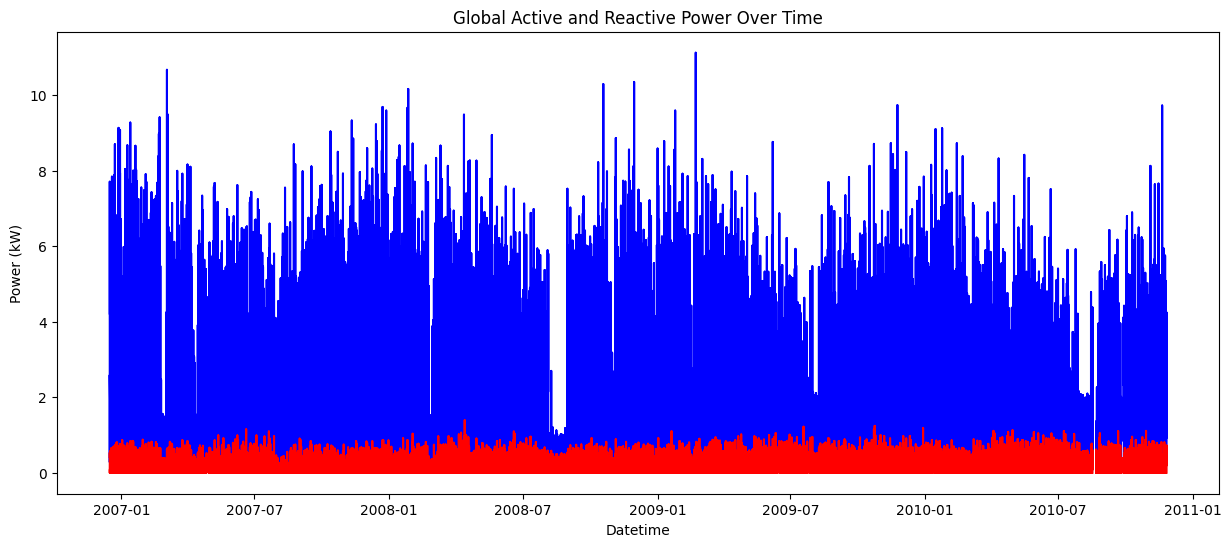

In [22]:
plt.figure(figsize=(15, 6))
plt.plot(df['Datetime'], df['Global_active_power'], label='Global Active Power', color='blue')
plt.plot(df['Datetime'], df['Global_reactive_power'], label='Global Reactive Power', color='red')
plt.xlabel('Datetime')
plt.ylabel('Power (kW)')
plt.title('Global Active and Reactive Power Over Time')
plt.show()